In [1]:
import os
import sys

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, hour, dayofweek, to_date, count, avg, when, sin, cos, lit,
    lag, unix_timestamp, stddev
)
from pyspark.sql import Window
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import matplotlib.pyplot as plt
import math
import time

In [3]:
spark = SparkSession.builder \
    .appName("BigDataProject_ML_Modeling") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

In [4]:
full_df = spark.read.option("header", "true").option("inferSchema", "true").csv("combined_dataset")
full_df.printSchema()
print("Rows loaded:", full_df.count())

root
 |-- operator_ref: string (nullable = true)
 |-- route_number: string (nullable = true)
 |-- pulled_at: timestamp (nullable = true)
 |-- recorded_at: timestamp (nullable = true)
 |-- vehicle_ref: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- bearing: integer (nullable = true)
 |-- avl_id: long (nullable = true)
 |-- avl_time_of_day: integer (nullable = true)
 |-- source_file: string (nullable = true)
 |-- service_ref: string (nullable = true)
 |-- line_ref: string (nullable = true)
 |-- journey_code: string (nullable = true)
 |-- departure_time: timestamp (nullable = true)
 |-- days_of_week: string (nullable = true)
 |-- stop_count: integer (nullable = true)
 |-- sched_time_of_day: integer (nullable = true)
 |-- time_diff: integer (nullable = true)
 |-- disruption_count: integer (nullable = true)
 |-- avg_disruption_duration: double (nullable = true)
 |-- avg_fare_gbp: double (nullable = true)

Rows loaded: 128621


In [5]:
demand_df = full_df.groupBy(
    "route_number",
    "operator_ref",
    to_date("recorded_at").alias("date"),
    hour("recorded_at").alias("hour_of_day")
).agg(
    count("*").alias("demand"),
    avg("disruption_count").alias("disruption_count"),
    avg("avg_disruption_duration").alias("avg_disruption_duration"),
    avg("avg_fare_gbp").alias("avg_fare_gbp")
)

print("Rows in demand table:", demand_df.count())
demand_df.show(10)

Rows in demand table: 554
+------------+------------+----------+-----------+------+----------------+-----------------------+------------------+
|route_number|operator_ref|      date|hour_of_day|demand|disruption_count|avg_disruption_duration|      avg_fare_gbp|
+------------+------------+----------+-----------+------+----------------+-----------------------+------------------+
|          17|        TDTR|2026-07-20|         19|   840|             5.0|                  126.0| 3.189354473386179|
|          50|        WDBC|2026-07-20|          0|   192|            16.0|                98.9375|3.1657190635451524|
|          86|        WDBC|2026-07-20|         18|   131|            10.0|                   92.5| 3.165719063545152|
|         U6H|        UNIL|2026-07-20|         13|   192|            11.0|     108.18181818181819|1.6307692307692314|
|         R26|        TDTR|2026-07-20|         19|    53|            11.0|     142.81818181818178|3.1893544733861843|
|          30|        WDBC|202

In [6]:
demand_df = demand_df.withColumn("day_of_week", dayofweek("date"))
demand_df = demand_df.withColumn(
    "is_weekend",
    when(col("day_of_week").isin([1, 7]), 1).otherwise(0)
)
demand_df = demand_df.withColumn("hour_sin", sin(col("hour_of_day") * (2 * lit(math.pi) / 24)))
demand_df = demand_df.withColumn("hour_cos", cos(col("hour_of_day") * (2 * lit(math.pi) / 24)))

demand_df.show(5)

+------------+------------+----------+-----------+------+----------------+-----------------------+------------------+-----------+----------+--------------------+--------------------+
|route_number|operator_ref|      date|hour_of_day|demand|disruption_count|avg_disruption_duration|      avg_fare_gbp|day_of_week|is_weekend|            hour_sin|            hour_cos|
+------------+------------+----------+-----------+------+----------------+-----------------------+------------------+-----------+----------+--------------------+--------------------+
|          17|        TDTR|2026-07-20|         19|   840|             5.0|                  126.0| 3.189354473386179|          2|         0| -0.9659258262890684|  0.2588190451025203|
|          50|        WDBC|2026-07-20|          0|   192|            16.0|                98.9375|3.1657190635451524|          2|         0|                 0.0|                 1.0|
|          86|        WDBC|2026-07-20|         18|   131|            10.0|           

In [7]:
demand_df = demand_df.fillna({
    "disruption_count": 0.0,
    "avg_disruption_duration": 0.0,
    "avg_fare_gbp": 0.0
})

In [8]:
train_raw, test_raw = demand_df.randomSplit([0.8, 0.2], seed=42)
print("Train rows:", train_raw.count())
print("Test rows:", test_raw.count())

Train rows: 470
Test rows: 84


In [9]:
route_avg_lookup = train_raw.groupBy("route_number", "operator_ref").agg(
    avg("demand").alias("route_avg_demand")
)

train_df_full = train_raw.join(route_avg_lookup, on=["route_number", "operator_ref"], how="left")
test_df_full = test_raw.join(route_avg_lookup, on=["route_number", "operator_ref"], how="left")

# Test-set routes not seen in training fall back to the overall training mean
overall_mean = train_raw.select(avg("demand")).collect()[0][0]
train_df_full = train_df_full.fillna({"route_avg_demand": overall_mean})
test_df_full = test_df_full.fillna({"route_avg_demand": overall_mean})

In [10]:
feature_cols = [
    "hour_sin", "hour_cos", "day_of_week", "is_weekend",
    "disruption_count", "avg_disruption_duration", "avg_fare_gbp",
    "route_avg_demand"
]
target_col = "demand"

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
train_assembled = assembler.transform(train_df_full)
test_assembled = assembler.transform(test_df_full)

scaler = StandardScaler(inputCol="features", outputCol="ScaledFeatures", withMean=True, withStd=True)
scaler_model = scaler.fit(train_assembled)

train_scaled = scaler_model.transform(train_assembled)
test_scaled = scaler_model.transform(test_assembled)

train_scaled.select("features", target_col).show(5, truncate=False)

+--------------------------------------------------------------------------------------------------+------+
|features                                                                                          |demand|
+--------------------------------------------------------------------------------------------------+------+
|[-0.9659258262890684,0.2588190451025203,2.0,0.0,11.0,159.9090909090911,2.940955284552843,1344.0]  |1627  |
|[-0.866025403784439,0.49999999999999933,2.0,0.0,11.0,159.90909090909085,2.9409552845528433,1344.0]|1061  |
|[-0.9659258262890681,-0.2588190451025215,2.0,0.0,13.0,104.84615384615392,3.0749303621169894,512.0]|384   |
|[-0.9659258262890684,0.2588190451025203,2.0,0.0,13.0,104.84615384615405,3.074930362116989,512.0]  |628   |
|[-0.866025403784439,0.49999999999999933,2.0,0.0,13.0,104.84615384615398,3.074930362116988,512.0]  |524   |
+--------------------------------------------------------------------------------------------------+------+
only showing top 5 rows



In [11]:
lr = LinearRegression(featuresCol="ScaledFeatures", labelCol=target_col, maxIter=100, regParam=0.01)
rf = RandomForestRegressor(featuresCol="ScaledFeatures", labelCol=target_col, numTrees=50, maxDepth=5, seed=42)
gbt = GBTRegressor(featuresCol="ScaledFeatures", labelCol=target_col, maxIter=50, maxDepth=5, seed=42)

In [12]:
start = time.time(); lr_model = lr.fit(train_scaled); lr_time = time.time() - start
start = time.time(); rf_model = rf.fit(train_scaled); rf_time = time.time() - start
start = time.time(); gbt_model = gbt.fit(train_scaled); gbt_time = time.time() - start

print("LR training time:", lr_time, "s")
print("RF training time:", rf_time, "s")
print("GBT training time:", gbt_time, "s")

LR training time: 4.858797788619995 s
RF training time: 3.187363624572754 s
GBT training time: 15.930525541305542 s


In [13]:
lr_predictions = lr_model.transform(test_scaled)
rf_predictions = rf_model.transform(test_scaled)
gbt_predictions = gbt_model.transform(test_scaled)

In [14]:
def evaluate_model(name, predictions, train_seconds):
    rmse = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="rmse").evaluate(predictions)
    mae = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="mae").evaluate(predictions)
    r2 = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="r2").evaluate(predictions)
    model_efficiency = r2 / train_seconds if train_seconds > 0 else 0
    print(f"{name}: RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}, Model Efficiency={model_efficiency:.5f}")
    return {"name": name, "rmse": rmse, "mae": mae, "r2": r2, "model_efficiency": model_efficiency}

results = []
results.append(evaluate_model("Linear Regression", lr_predictions, lr_time))
results.append(evaluate_model("Random Forest", rf_predictions, rf_time))
results.append(evaluate_model("Gradient Boosted Trees", gbt_predictions, gbt_time))

Linear Regression: RMSE=178.470, MAE=120.854, R2=0.525, Model Efficiency=0.10809
Random Forest: RMSE=184.193, MAE=114.230, R2=0.494, Model Efficiency=0.15506
Gradient Boosted Trees: RMSE=144.411, MAE=96.697, R2=0.689, Model Efficiency=0.04326


In [15]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator

evaluator_r2 = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="r2")

gbt_grid = ParamGridBuilder() \
    .addGrid(gbt.maxDepth, [3, 5, 7]) \
    .build()
gbt_cv = CrossValidator(
    estimator=gbt,
    estimatorParamMaps=gbt_grid,
    evaluator=evaluator_r2,
    numFolds=5,
    seed=42
)

gbt_cv_model = gbt_cv.fit(train_scaled)
print("GBT best avg R² across 5 folds (training data only):", max(gbt_cv_model.avgMetrics))

gbt_cv_predictions = gbt_cv_model.transform(test_scaled)
final_r2 = evaluator_r2.evaluate(gbt_cv_predictions)
print("Final GBT R² on held-out test set:", final_r2)

GBT best avg R² across 5 folds (training data only): 0.5795123283188549
Final GBT R² on held-out test set: 0.5835808752244773


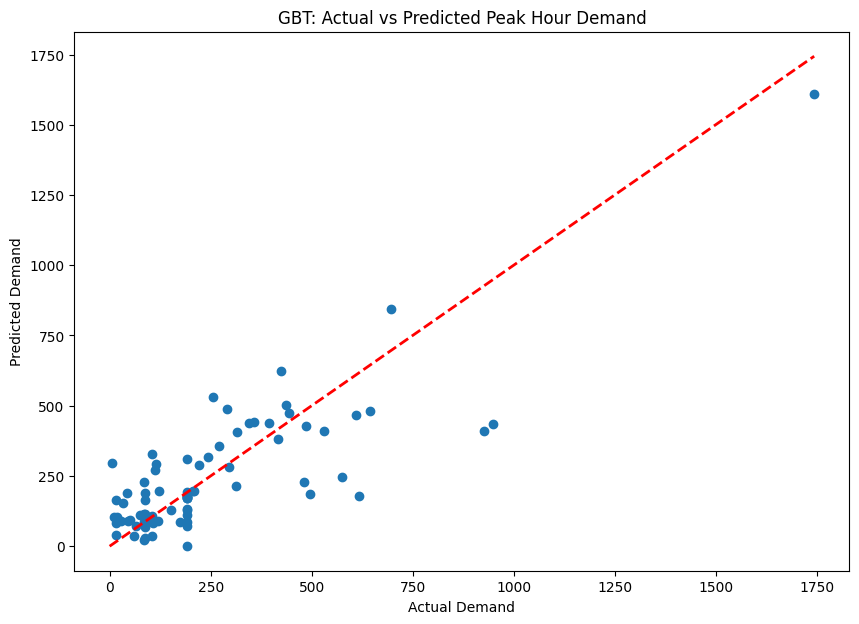

In [16]:
gbt_pred_pandas = gbt_predictions.select(
    col(target_col).alias("Actual"),
    col("prediction").alias("Predicted")
).toPandas()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(gbt_pred_pandas["Actual"], gbt_pred_pandas["Predicted"])
max_val = gbt_pred_pandas["Actual"].max()
ax.plot([0, max_val], [0, max_val], "r--", lw=2)
ax.set_xlabel("Actual Demand")
ax.set_ylabel("Predicted Demand")
ax.set_title("GBT: Actual vs Predicted Peak Hour Demand")
plt.show()

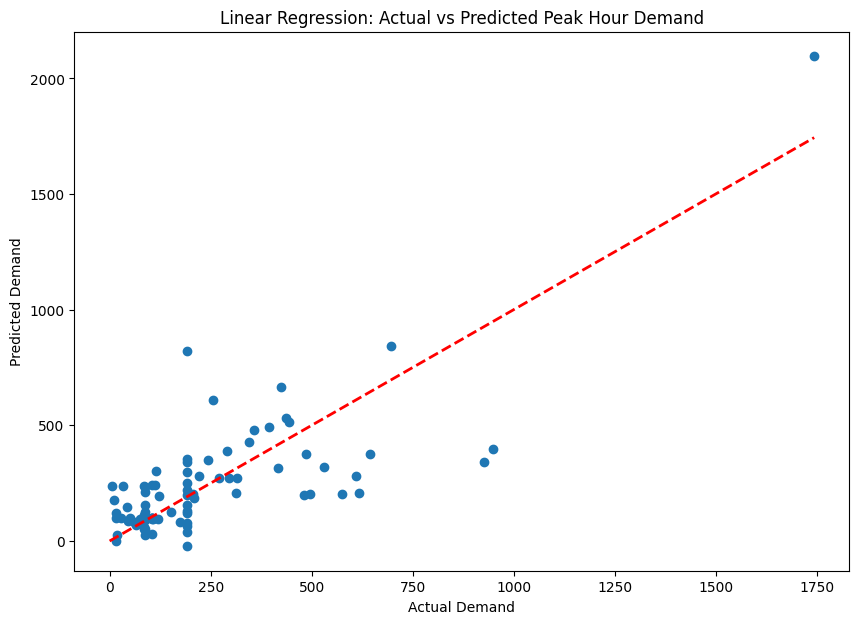

In [17]:
lr_pred_pandas = lr_predictions.select(
    col(target_col).alias("Actual"),
    col("prediction").alias("Predicted")
).toPandas()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(lr_pred_pandas["Actual"], lr_pred_pandas["Predicted"])
max_val = lr_pred_pandas["Actual"].max()
ax.plot([0, max_val], [0, max_val], "r--", lw=2)
ax.set_xlabel("Actual Demand")
ax.set_ylabel("Predicted Demand")
ax.set_title("Linear Regression: Actual vs Predicted Peak Hour Demand")
plt.show()

In [18]:
from pyspark.sql.functions import countDistinct

from pyspark.sql.functions import date_trunc

vehicle_minute_df = full_df.withColumn(
    "minute_bucket", date_trunc("minute", col("recorded_at"))
).select("route_number", "operator_ref", "vehicle_ref", "minute_bucket").distinct()

headway_window = Window.partitionBy("route_number", "operator_ref").orderBy("minute_bucket")

vehicle_with_lag = vehicle_minute_df.withColumn(
    "prev_minute", lag("minute_bucket").over(headway_window)
)

vehicle_with_headway = vehicle_with_lag.withColumn(
    "headway_seconds",
    unix_timestamp("minute_bucket") - unix_timestamp("prev_minute")
).filter(col("headway_seconds").isNotNull() & (col("headway_seconds") > 0))

headway_summary = vehicle_with_headway.groupBy("route_number", "operator_ref").agg(
    avg("headway_seconds").alias("mean_headway_seconds"),
    stddev("headway_seconds").alias("stddev_headway_seconds")
)

headway_summary = headway_summary.withColumn(
    "headway_regularity_pct",
    (col("stddev_headway_seconds") / col("mean_headway_seconds")) * 100
)

headway_summary.orderBy("mean_headway_seconds", ascending=False).show(15, truncate=False)

+------------+------------+--------------------+----------------------+----------------------+
|route_number|operator_ref|mean_headway_seconds|stddev_headway_seconds|headway_regularity_pct|
+------------+------------+--------------------+----------------------+----------------------+
|209         |SVCT        |16560.0             |NULL                  |NULL                  |
|SL          |SVCT        |6894.545454545455   |22667.62288535627     |328.7761758160852     |
|L5          |WDBC        |2060.0              |6928.203230275509     |336.3205451590053     |
|19          |BLUS        |1469.4545454545455  |9454.90964333538      |643.4298816919647     |
|60          |WDBC        |1433.2075471698113  |9997.101844185587     |697.5334356790892     |
|539         |BLUS        |1395.7894736842106  |5822.571325634857     |417.1525459542318     |
|13          |BLUS        |1387.9245283018868  |9667.436490708733     |696.5390620004933     |
|21          |WDBC        |1377.7358490566037  |95

In [19]:
headway_summary = headway_summary.withColumn(
    "meets_regularity_threshold",
    when(col("headway_regularity_pct") <= 20, True).otherwise(False)
)

headway_summary.groupBy("meets_regularity_threshold").count().show()

+--------------------------+-----+
|meets_regularity_threshold|count|
+--------------------------+-----+
|                      true|  124|
|                     false|  114|
+--------------------------+-----+



In [20]:
import pandas as pd

# Export predictions from all 3 models
lr_predictions.select("route_number", "operator_ref", "hour_of_day", "day_of_week", target_col, "prediction") \
    .toPandas().to_csv("lr_predictions.csv", index=False)

rf_predictions.select("route_number", "operator_ref", "hour_of_day", "day_of_week", target_col, "prediction") \
    .toPandas().to_csv("rf_predictions.csv", index=False)

gbt_predictions.select("route_number", "operator_ref", "hour_of_day", "day_of_week", target_col, "prediction") \
    .toPandas().to_csv("gbt_predictions.csv", index=False)

# Export the model comparison metrics table
metrics_df = pd.DataFrame(results)
metrics_df.to_csv("model_metrics.csv", index=False)

# Export the headway regularity table
headway_summary.toPandas().to_csv("headway_summary.csv", index=False)

print("Exported: lr_predictions.csv, rf_predictions.csv, gbt_predictions.csv, model_metrics.csv, headway_summary.csv")

Exported: lr_predictions.csv, rf_predictions.csv, gbt_predictions.csv, model_metrics.csv, headway_summary.csv


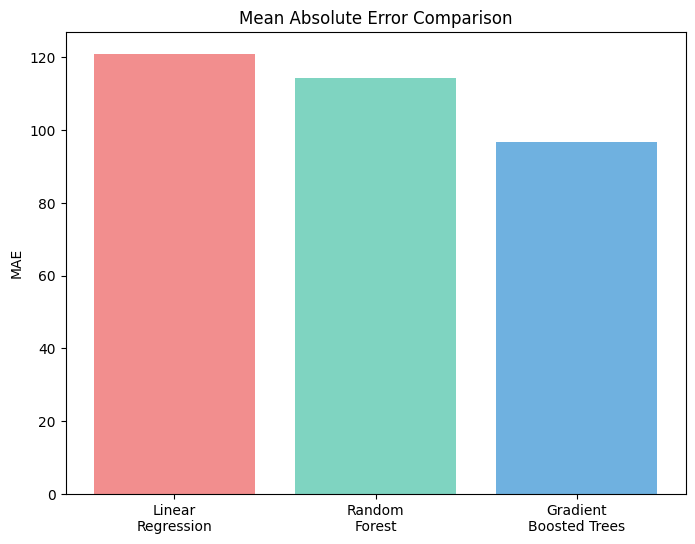

In [21]:
mae_values = [120.85, 114.23, 96.70]  # replace with your exact confirmed values
models = ["Linear\nRegression", "Random\nForest", "Gradient\nBoosted Trees"]

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(models, mae_values, color=["#f28e8e", "#7fd4c1", "#6fb1e0"])
ax.set_ylabel("MAE")
ax.set_title("Mean Absolute Error Comparison")
plt.show()

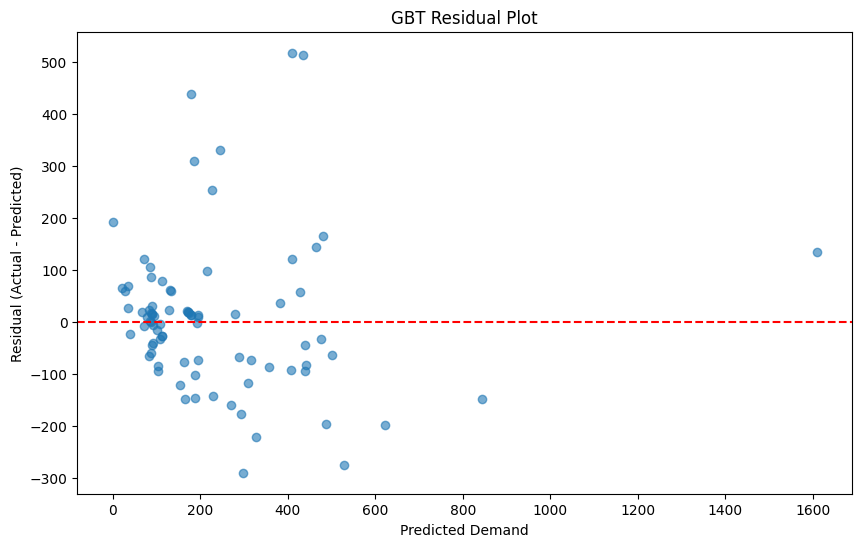

In [22]:
gbt_pred_pandas = gbt_predictions.select(col(target_col).alias("Actual"), col("prediction").alias("Predicted")).toPandas()
gbt_pred_pandas["Residual"] = gbt_pred_pandas["Actual"] - gbt_pred_pandas["Predicted"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(gbt_pred_pandas["Predicted"], gbt_pred_pandas["Residual"], alpha=0.6)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Predicted Demand")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title("GBT Residual Plot")
plt.show()

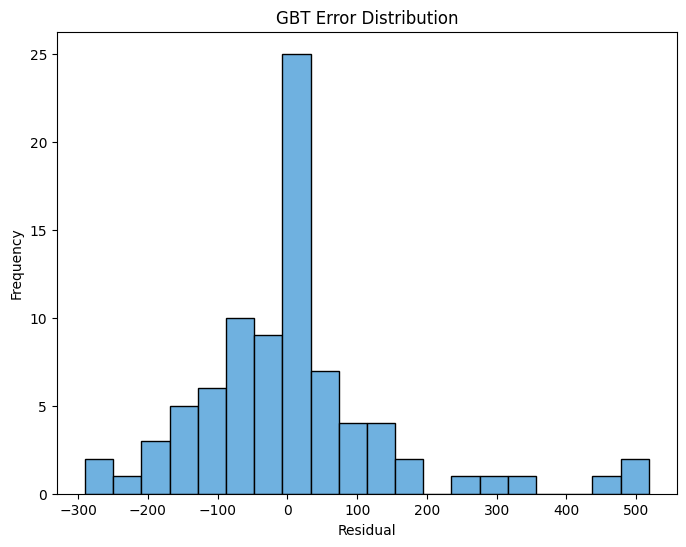

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(gbt_pred_pandas["Residual"], bins=20, edgecolor="black", color="#6fb1e0")
ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
ax.set_title("GBT Error Distribution")
plt.show()

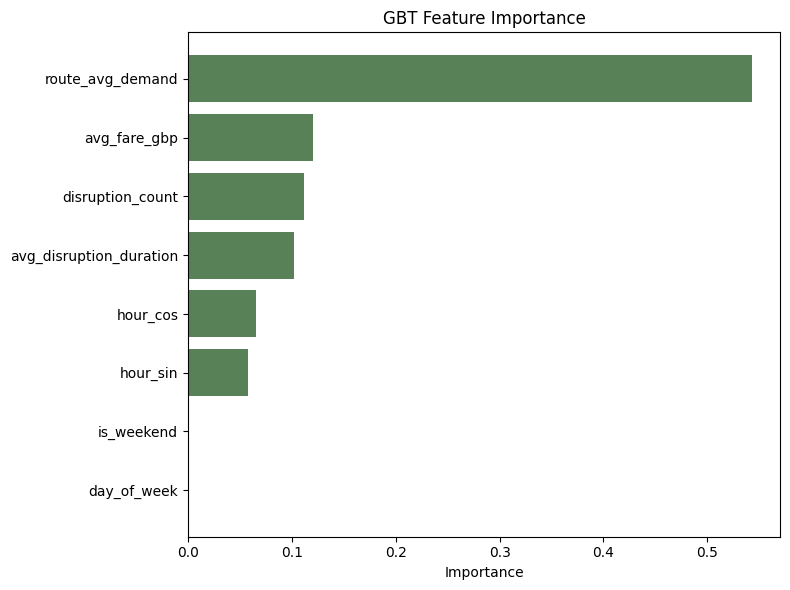

In [24]:
import pandas as pd
importances = gbt_model.featureImportances.toArray()
importance_pandas = pd.DataFrame({"feature": feature_cols, "importance": importances}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_pandas["feature"], importance_pandas["importance"], color="#588157")
ax.set_xlabel("Importance")
ax.set_title("GBT Feature Importance")
plt.tight_layout()
plt.show()

In [25]:
for feature, importance in zip(importance_pandas["feature"], importance_pandas["importance"]):
    print(f"{feature}: {importance:.4f}")

day_of_week: 0.0000
is_weekend: 0.0000
hour_sin: 0.0578
hour_cos: 0.0656
avg_disruption_duration: 0.1025
disruption_count: 0.1113
avg_fare_gbp: 0.1199
route_avg_demand: 0.5428
